### Auto-Generated Code Cells

The following code cells contain code from external .py files that has been automatically added to remove these dependencies. This allows you to run this version of the SELENE notebook on Cloud platforms such as Google Colab. Run all following code cells before starting with the actual notebook content. 

Most Cloud platforms such as Google Colab have a wide range of Python packages preinstalled. However, if any import statements in the following code cells throws an error because of a missing package, you can create and run a new code cell to install the missing package using the `pip` command as shown here:
```
!pip install <package-name>
```

You can use the code cell below for convenience.

In [ ]:
#!pip install <package-name>

In [ ]:
# === Inline content for module src.models.trees.dtree  ==

# === Inlined imports ===
import numpy as np

# === Embedded configs ===


# === Inlined definitions ===
def generate_split(self, feature_values: list[int | float], threshold: int | float):
    indices_left = np.where(feature_values <= threshold)[0]
    indices_right = np.where(feature_values > threshold)[0]
    return (indices_left, indices_right)

def compute_gini_score_split(self, y_left, y_right):
    gini_score_left = self.compute_gini_score_node(y_left)
    gini_score_right = self.compute_gini_score_node(y_right)
    return len(y_left) / (len(y_left) + len(y_right)) * gini_score_left + len(y_right) / (len(y_left) + len(y_right)) * gini_score_right

def sample_feature_indices(self, X):
    n_features = X.shape[1]
    if self.max_features is not None:
        n_features = min(n_features, self.max_features)
    return np.random.choice(np.arange(X.shape[1]), size=n_features, replace=False)

def compute_thresholds(self, feature_values):
    values_sorted = np.unique(feature_values)
    return (values_sorted[:-1] + values_sorted[1:]) / 2.0

def get_targets(self, X):
    return [self.get_targets_for_sample(self.tree, x) for x in X]

class SeleneDecisionTree:

    def __init__(self, max_depth: int=None, min_samples_split: int=2, max_features: int=None):
        if max_depth is not None and max_depth < 1:
            raise Exception('If specified, max_depth must be greater or equal to 0')
        if min_samples_split is not None and min_samples_split < 1:
            raise Exception('If specified, min_samples_split must be greater or equal to 0')
        if max_features is not None and max_features < 1:
            raise Exception('If specified, max_features must be greater or equal to 1')
        self.tree = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features

    def compute_thresholds(self, feature_values):
        values_sorted = np.unique(feature_values)
        return (values_sorted[:-1] + values_sorted[1:]) / 2.0

    def generate_split(self, feature_values: list[int | float], threshold: int | float):
        indices_left = np.where(feature_values <= threshold)[0]
        indices_right = np.where(feature_values > threshold)[0]
        return (indices_left, indices_right)

    def sample_feature_indices(self, X):
        n_features = X.shape[1]
        if self.max_features is not None:
            n_features = min(n_features, self.max_features)
        return np.random.choice(np.arange(X.shape[1]), size=n_features, replace=False)

    def find_best_feature_split(self, x, y, split_scoring_func):
        best_score, best_threshold, best_split = (np.inf, None, None)
        thresholds = self.compute_thresholds(x)
        for threshold in thresholds:
            split = self.generate_split(x, threshold)
            y_left, y_right = (y[split[0]], y[split[1]])
            score = split_scoring_func(y_left, y_right)
            if score < best_score:
                best_score, best_threshold, best_split = (score, threshold, split)
        return (best_score, best_threshold, best_split)

    def find_best_split(self, X, y, split_scoring_func):
        best_score, best_threshold, best_fidx, best_split = (np.inf, None, None, None)
        sampled_feature_indices = self.sample_feature_indices(X)
        for fidx in sampled_feature_indices:
            x = X[:, fidx]
            score, threshold, split = self.find_best_feature_split(x, y, split_scoring_func)
            if score <= best_score:
                best_score, best_split, best_fidx, best_threshold = (score, split, fidx, threshold)
        return (best_score, best_threshold, best_fidx, best_split)

    def fit(self, X, y, node_scoring_func, split_scoring_func):
        self.tree = Node(y)
        self._fit(X, y, self.tree, node_scoring_func, split_scoring_func)
        return self

    def _fit(self, X, y, node, node_scoring_func, split_scoring_func, depth=0):
        node.score = node_scoring_func(y)
        if self.max_depth is not None and depth >= self.max_depth:
            return
        if self.min_samples_split is not None and self.min_samples_split > len(node.y):
            return
        if len(np.unique(y)) == 1:
            return
        score, threshold, idx, split = self.find_best_split(X, y, split_scoring_func)
        if score > node.score:
            return
        X_left, X_right = (X[split[0]], X[split[1]])
        y_left, y_right = (y[split[0]], y[split[1]])
        node.feature_idx = idx
        node.threshold = threshold
        node.left_child = Node(y_left)
        node.right_child = Node(y_right)
        self._fit(X_left, y_left, node.left_child, node_scoring_func, split_scoring_func, depth=depth + 1)
        self._fit(X_right, y_right, node.right_child, node_scoring_func, split_scoring_func, depth=depth + 1)

    def get_targets(self, X):
        return [self.get_targets_for_sample(self.tree, x) for x in X]

    def get_targets_for_sample(self, node, x):
        if node.is_leaf():
            return node.y
        go_left = False
        if x[node.feature_idx] <= node.threshold:
            go_left = True
        if go_left:
            return self.get_targets_for_sample(node.left_child, x)
        else:
            return self.get_targets_for_sample(node.right_child, x)

    def __str__(self):
        self.print_tree(self.tree)
        return ''

    def print_tree(self, node, level=0):
        print('---' * level, node)
        if node.left_child is not None:
            self.print_tree(node.left_child, level=level + 1)
        if node.right_child is not None:
            self.print_tree(node.right_child, level=level + 1)

class SeleneDecisionTreeClassifier(SeleneDecisionTree):

    def __init__(self, max_depth: int=None, min_samples_split: int=2, max_features: int=None):
        super().__init__(max_depth=max_depth, min_samples_split=min_samples_split, max_features=max_features)

    def compute_gini_score_node(self, y):
        _, counts = np.unique(y, return_counts=True)
        return 1 - np.sum(np.square(counts / len(y)))

    def compute_gini_score_split(self, y_left, y_right):
        gini_score_left = self.compute_gini_score_node(y_left)
        gini_score_right = self.compute_gini_score_node(y_right)
        return len(y_left) / (len(y_left) + len(y_right)) * gini_score_left + len(y_right) / (len(y_left) + len(y_right)) * gini_score_right

    def fit(self, X, y):
        return super().fit(X, y, self.compute_gini_score_node, self.compute_gini_score_split)

    def predict(self, X):
        targets = self.get_targets(X)
        return [np.bincount(t).argmax() for t in targets]

class SeleneDecisionTreeRegressor(SeleneDecisionTree):

    def __init__(self, max_depth: int=None, min_samples_split: int=2, max_features: int=None):
        super().__init__(max_depth=max_depth, min_samples_split=min_samples_split, max_features=max_features)

    def compute_rss_score_node(self, y):
        mean = np.mean(y)
        rss_score = np.sum(np.square(y - mean)) / len(y)
        return rss_score

    def compute_rss_score_split(self, y_left, y_right):
        mean_left = np.mean(y_left)
        mean_right = np.mean(y_right)
        rss_score_left = np.sum(np.square(y_left - mean_left)) / len(y_left)
        rss_score_right = np.sum(np.square(y_right - mean_right)) / len(y_right)
        return len(y_left) / (len(y_left) + len(y_right)) * rss_score_left + len(y_right) / (len(y_left) + len(y_right)) * rss_score_right

    def fit(self, X, y):
        return super().fit(X, y, self.compute_rss_score_node, self.compute_rss_score_split)

    def predict(self, X):
        targets = self.get_targets(X)
        return [np.mean(t) for t in targets]

def find_best_split(self, X, y, split_scoring_func):
    best_score, best_threshold, best_fidx, best_split = (np.inf, None, None, None)
    sampled_feature_indices = self.sample_feature_indices(X)
    for fidx in sampled_feature_indices:
        x = X[:, fidx]
        score, threshold, split = self.find_best_feature_split(x, y, split_scoring_func)
        if score <= best_score:
            best_score, best_split, best_fidx, best_threshold = (score, split, fidx, threshold)
    return (best_score, best_threshold, best_fidx, best_split)

def fit(self, X, y):
    return super().fit(X, y, self.compute_rss_score_node, self.compute_rss_score_split)

def is_leaf(self):
    if self.feature_idx is None:
        return True
    else:
        return False

def find_best_feature_split(self, x, y, split_scoring_func):
    best_score, best_threshold, best_split = (np.inf, None, None)
    thresholds = self.compute_thresholds(x)
    for threshold in thresholds:
        split = self.generate_split(x, threshold)
        y_left, y_right = (y[split[0]], y[split[1]])
        score = split_scoring_func(y_left, y_right)
        if score < best_score:
            best_score, best_threshold, best_split = (score, threshold, split)
    return (best_score, best_threshold, best_split)

def predict(self, X):
    targets = self.get_targets(X)
    return [np.mean(t) for t in targets]

class Node:
    """
    Implements an individual node in the Decision Tree. 
    """

    def __init__(self, y):
        self.y = y
        self.score = np.inf
        self.feature_idx = None
        self.threshold = None
        self.left_child = None
        self.right_child = None

    def is_leaf(self):
        if self.feature_idx is None:
            return True
        else:
            return False

    def __str__(self):
        if self.is_leaf() == True:
            return f'Leaf, gini: {self.score:.3f}, samples: {self.y}'
        else:
            return f'X[{self.feature_idx}], threshold={self.threshold:.3g}, score={self.score:.3g}, samples={self.y}'

def get_targets_for_sample(self, node, x):
    if node.is_leaf():
        return node.y
    go_left = False
    if x[node.feature_idx] <= node.threshold:
        go_left = True
    if go_left:
        return self.get_targets_for_sample(node.left_child, x)
    else:
        return self.get_targets_for_sample(node.right_child, x)

def compute_gini_score_node(self, y):
    _, counts = np.unique(y, return_counts=True)
    return 1 - np.sum(np.square(counts / len(y)))

In [ ]:
# === Inline content for module src.utils.data.files  ==

# === Inlined imports ===
import os, re, yaml
import requests
import bz2
import zipfile, tarfile
from tqdm import tqdm

# === Embedded configs ===
CONFIG = yaml.safe_load("""urls:
  downloads:
    notebooks: "https://github.com/chrisvdweth/selene/tree/master/notebooks"
    datasets: "https://chrisvdw.net/projects/selene/downloads/datasets/"
    models: "https://chrisvdw.net/projects/selene/downloads/models/"
    """)

# === Inlined definitions ===
def download_file(url, download_path, overwrite=False, ignore_html=False):
    file_name = url.split('/')[-1]
    create_folder(download_path)
    file_path = download_path + file_name
    if os.path.isfile(file_path) == True and overwrite is not True:
        print(f"File '{file_path}' already exists (use 'overwrite=True' to overwrite it).")
        return (file_path, download_path)
    response = requests.get(url, stream=True)
    total_size_in_bytes = int(response.headers.get('content-length', 0))
    block_size = 1024
    progress_bar = tqdm(total=total_size_in_bytes, unit='iB', unit_scale=True)
    with open(file_path, 'wb') as file:
        for data in response.iter_content(block_size):
            if ignore_html is True and is_html_file(data) is True:
                print('Error downloading file (expected data file, got HTML file)')
                return (None, None)
            progress_bar.update(len(data))
            file.write(data)
    progress_bar.close()
    if total_size_in_bytes != 0 and progress_bar.n != total_size_in_bytes:
        print('Error downloading file (source does not exist)')
        return (None, None)
    return (file_path, download_path)

def is_html_file(content):
    content = content.decode('utf-8', 'ignore').strip().lower()
    if content.startswith('<!doctype html') is True:
        return True
    elif content.startswith('<html') is True:
        return True
    return False

def download_dataset(dataset_path, base_url=None, download_path=None, overwrite=False, ignore_html=True):
    if base_url is None:
        base_url = CONFIG['urls']['downloads']['datasets']
    if download_path is None:
        download_path = 'data/datasets/' + '/'.join(dataset_path.split('/')[0:-1]) + '/'
    url = base_url + dataset_path
    return download_file(url, download_path=download_path, overwrite=overwrite, ignore_html=ignore_html)

def create_folder(folder_name, exist_ok=True):
    try:
        os.makedirs(folder_name, exist_ok=exist_ok)
        return folder_name
    except:
        return None

<img src="https://raw.githubusercontent.com/chrisvdweth/selene/refs/heads/master/notebooks/images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Decision Trees &mdash; Implementation from Scratch

Decision Trees are among the most intuitive and widely used machine learning models. Their appeal comes from the fact that they mimic a sequence of human-like decisions: at each step, the model asks a simple question about the data and progressively narrows down the prediction. Despite their conceptual simplicity, Decision Trees form the foundation of many powerful modern machine learning methods, including Random Forests and Gradient Boosted Trees. Understanding how they operate internally provides valuable insight into core machine learning concepts such as recursive partitioning, impurity reduction, model complexity, and overfitting.

In practice, most developers rely on highly optimized libraries such as [scikit-learn](https://scikit-learn.org) to train Decision Trees with only a few lines of code. While these implementations are efficient and production-ready, they often abstract away the underlying mechanics that make the algorithm work. This notebook takes the opposite approach: instead of treating the model as a black box, we will build simplified versions of the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class and the [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) class from scratch in order to understand each component of the learning process in detail.

The implementations in this notebook follow the general principles of the [scikit-learn](https://scikit-learn.org) (Classification and Regression Trees) algorithm. However, to keep the code concise and focused on the key ideas, we make the same two important simplifications as the implementations in [scikit-learn](https://scikit-learn.org). First, we assume that all input features are numerical. Second, we restrict the tree to binary splits only, meaning each node divides the data into exactly two branches. These constraints allow us to concentrate on the essential logic of split selection, impurity minimization, recursion, stopping criteria, and prediction generation without being distracted by implementation details required for handling more general cases.

The purpose of this notebook is educational rather than practical. The goal is not to outperform or replace mature machine learning libraries, but to develop a deeper intuition for how Decision Trees operate under the hood. By implementing every step ourselves &mdash; from evaluating candidate thresholds to recursively constructing the tree structure &mdash; we gain a clearer understanding of both the strengths and limitations of tree-based methods. This hands-on perspective also makes it easier to reason about concepts such as interpretability, computational efficiency, pruning, and ensemble learning methods built on top of Decision Trees.

Let's dive in!

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.tree import plot_tree


#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [3]:
loan_data ,_     = download_dataset("tabular/classification/example-loan-default-data.csv")
breast_cancer, _ = download_dataset("tabular/classification/breast-cancer-wisconsin-classification.csv")

File 'data/datasets/tabular/classification/example-loan-default-data.csv' already exists (use 'overwrite=True' to overwrite it).
File 'data/datasets/tabular/classification/breast-cancer-wisconsin-classification.csv' already exists (use 'overwrite=True' to overwrite it).


#### Preparation of Toy Dataset

Throughout this notebook, we use a very small synthetic dataset so we can clearly follow each individual step. This dataset contains the historical information about loan applications for $10$ bank customers. Let's first load the dataset file into a Pandas DataFrame and have a look at the different values.

In [4]:
df_loan = pd.read_csv(loan_data)

df_loan.head(15)

,ANNUAL_INCOME,CREDIT_SCORE,DEBT_RATIO,YEARS_EMPLOYED,DEFAULTED,LOAN_AMOUNT
0,45,620,0.42,2,1,28
1,82,710,0.21,8,1,32
2,60,680,0.35,5,0,30
3,38,590,0.51,1,1,12
4,95,760,0.18,12,0,15
5,72,700,0.29,7,0,38
6,50,640,0.47,3,1,20
7,11,790,0.15,15,0,70
8,67,675,0.33,6,0,34
9,40,605,0.49,2,1,15


Note that, in this dataset, the values for the annual income and the loan amount are expressed in thousands; for example, an annual income value of $45$ means that the annual income of this customer is $45,000$ (we do not care about the currency here).

Throughout the notebook, we consider the annual income, the credit score, the debt ratio, and the years of employment as the input features for each customer. The information whether customers defaulted on their credit and the loan amount are considered potential targets, depending if we consider a classification or regression task. In case of a classification task, we want to use the input features to predict if a customer will default on their credit. For this, we can create the NumPy arrays `X` and `y` representing the feature matrix and target vector, respectively, as follows:

In [5]:
X_classification = df_loan.drop(["DEFAULTED", "LOAN_AMOUNT"], axis=1).to_numpy()
y_classification = df_loan["DEFAULTED"].to_numpy()

For the regression task, we assume we want to train a model predict the loan amount based on the input features; again, we can directly create the feature matrix `X` and target vector:

In [6]:
X_regression = df_loan.drop(["DEFAULTED", "LOAN_AMOUNT"], axis=1).to_numpy()
y_regression = df_loan["LOAN_AMOUNT"].to_numpy()

Later, when visualizing Decision Trees, it also helps to have all feature names as a list:

In [7]:
feature_names = ["INCOME", "SCORE", "RATIO", "YEARS"]

#### Preliminaries

Before checking out this notebook, please consider the following:

* This notebook assumes that you are already familiar with the basic concept of Decision Trees and the CART algorithm in particular. Both topics are covered in separate notebooks.

* The focus of this notebook is to go through the implementation for Decision trees step by step to deepen the understanding about their inner works. The implementation is not intended to replace the more mature and optimized implementations available in many libraries.

---

## Quick Recap: Decision Trees

Decision Trees are a supervised machine learning method used for both **classification and regression tasks**. The basic idea is to recursively split the dataset into smaller and more homogeneous groups based on the values of the input features. Starting from the root node, the algorithm searches for a feature and threshold that best separates the data according to some criterion, such as Gini impurity, entropy, or mean squared error. Each internal node in the tree represents a decision rule, each branch represents the outcome of that rule, and each leaf node contains the final prediction. During inference, a sample is passed through the tree by following the decision rules until it reaches a leaf node.

In principle, Decision Trees naturally support both numerical and categorical features, as well as an arbitrary number of branches for each split. However, many practical implementations, including those in [scikit-learn](https://scikit-learn.org), primarily assume **numerical input features** and perform only **binary splits** based on thresholds. One reason is computational efficiency: binary threshold splits are much easier and faster to optimize, especially for large datasets and high-dimensional feature spaces. Restricting the tree to binary splits also simplifies the implementation and leads to more uniform tree structures. As a result, categorical variables are often converted into numerical representations, such as one-hot encoding, before training. Although this may appear restrictive, binary-split trees remain highly expressive and can still model complex decision boundaries effectively.

To give an example, we can train a Decision Tree classifier using the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class provided by [scikit-learn](https://scikit-learn.org) on our toy dataset. The code cell below shows the minimal code example to accomplish this; note that the class provides a series of arguments (e.g., the maximum depth of the tree) that impact the training. For the example below, we stick to the default parameters. Note that we also set a random seed to ensure consistent results, as this implementation of Decision Trees has random components (incl. the random breaking of ties in case different alternatives to split a node are equally good).

In [8]:
np.random.seed(1)

sklearn_classifier = DecisionTreeClassifier().fit(X_classification, y_classification)

[scikit-learn](https://scikit-learn.org) also provides the auxiliary method `plot_tree()` to visualize the trained Decision Tree, which in our case is only a small tree since we only used a very small training dataset.

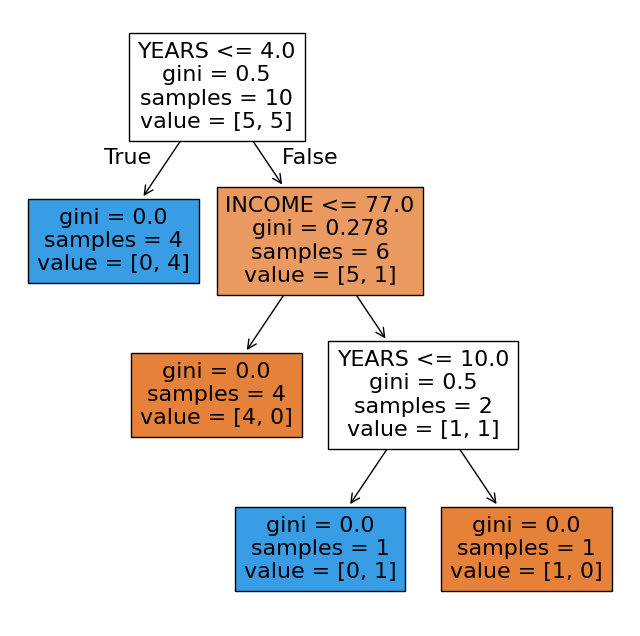

In [9]:
plt.figure(figsize=(8, 8))
plot_tree(sklearn_classifier, filled=True, feature_names=feature_names)
plt.show()

This visualization clearly shows the decision rule for each inner node (i.e., non-leaf node). For example, the root node is telling us that the first split depends on the years of employment and that the threshold value for this split is $4$ years. Thus all customers with less than or equal to $4$ years employment fall into the left branch, while all other customers fall into the right branch. Then the splitting of nodes continues until a node has only samples (here: customers) with the same class label.

In this example, we build the *full* Decision Tree, meaning growing the tree until no further meaningful splits can be made. In practice, this often means continuing the recursive splitting process until every leaf node contains only samples from a single class, only a very small number of samples, or no additional split can improve the impurity measure. Such a tree can become very deep and highly specialized to the training data. Because Decision Trees greedily optimize splits at each node, a fully grown tree may fit even small fluctuations and noise present in the dataset.

While a full tree can achieve extremely low training error, it often performs poorly on unseen data due to **overfitting**. The model effectively memorizes the training set instead of learning more general patterns. To address this problem, practical Decision Tree implementations usually restrict the size or complexity of the tree. Common approaches include limiting the maximum tree depth, requiring a minimum number of samples per split or other criteria, restricting the maximum number of leaf nodes, or applying pruning techniques that remove unnecessary branches after training. These constraints help produce simpler and more robust trees that generalize better to new data. We will therefore consider some of these techniques restricting the size of Decision Trees in our implementation.

**Goal:** In simple terms, the goal in this notebooks is to reimplement the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) class from scratch in Python using only NumPy. We cover each important step and explain in detail how it works. Just keep in mind that we keep things simple, which means that our complementation will not match the flexibility and capabilities of the implementations of [scikit-learn](https://scikit-learn.org). The purpose is to understand the core concepts behind Decision Trees.

---

## Implemention

In the following, we will go through all the core steps to build and train Decision Trees for both classification and regression tasks. For each step, we provide a basic implementation and examples show the inner workings. However, we also provide a more practical implementation combining all the steps into convenient classes. You can check out the `SeleneDecisionTreeClassifier` and `SeleneDecisionTreeRegressor` class in the file `src/models/trees/dtree.py`. Both classes inherit from the class `SeleneDecisionTree` which contains all steps common for Decision Tree classifiers and Decision Tree Regressors. We will use these classes for a practical application example at the end.

### Generating Splits

Decision Trees split each node based on a decision involving a single feature. For example, given our toy dataset, we might split a node based either on the years of employment or the annual income (or some other feature). Since we consider only numerical features and only binary splits, this decision simplifies which feature values are above or below some threshold. Of course, the choice of this threshold matters and training a Decision Trees involves finding the "best" threshold &mdash; recall that splits are chosen independently at each node based only on the current subset of data, making it a greedy, local optimization approach; as a result, a split that appears optimal at one node may lead to a suboptimal overall tree structure compared to a globally optimal solution.

The most straightforward way to find the best split is to consider all splits and measure which one should be preferred &mdash; the latter we do via some scoring described a bit later. Again, since we assume only numerical values, finding all meaningful splits is rather simple: The **candidate thresholds** for splitting a numeric feature are determined directly from the training data. Specifically, the feature values are first sorted, and the algorithm considers potential thresholds only at the **midpoints between consecutive distinct values**. For example, if the unique and sorted values of a feature are $[x_1, x_2, \dots, x_n]$, with $x_i < x_{i+1}$, then each candidate threshold $t$ is chosen as

$$\large
t = \frac{x_i + x_{i+1}}{2}
$$

The method `generate_split()` below implements this idea. The expression `np.where(feature_values <= threshold)[0]` returns the indices of all samples whose feature value is less than or equal to the threshold, while `np.where(feature_values > threshold)[0]` returns the indices of samples greater than the threshold. The method then returns these two index sets as the left and right child split, respectively.

In [10]:
def compute_thresholds(feature_values):
    # Get unique values to handle duplicates; return values will already be sorted
    values_sorted = np.unique(feature_values)
    # Compute and return all midpoints between consective values
    return (values_sorted[:-1] + values_sorted[1:]) / 2.0

To show an example, consider the feature reflecting the years of employment for each customer; this feature is a good example since it contains duplicate values. After extracting the feature values from the Pandas DateFrame, we can apply method `compute_thresholds()` to compute and print the thresholds.

In [11]:
years = df_loan.YEARS_EMPLOYED.to_numpy()
print(f"Years of emplayment for all customers:\n{years}\n")

years_thresholds = compute_thresholds(years)
print(f"All meaningful thresholds of years of employment:\n{years_thresholds}")

Years of emplayment for all customers:
[ 2  8  5  1 12  7  3 15  6  2]

All meaningful thresholds of years of employment:
[ 1.5  2.5  4.   5.5  6.5  7.5 10.  13.5]


**Note:** Evaluating all possible midpoints between unique feature values can become computationally expensive for large datasets, especially when features contain many distinct values. Therefore, practical Decision Tree implementations often use heuristics or approximations to improve training efficiency while maintaining good predictive performance. A simple way to reduce the number of candidate splits is to evaluate only a random subset of possible thresholds instead of all midpoints between unique values. Another common approach is to bin continuous features into intervals, so that splits are only considered at bin boundaries rather than at every unique value. However, for the purpose of this notebook, we consider all possible midpoints as thresholds as efficiency consideration are beyond our scope here.

Using a threshold, we can now split the feature values into groups: features values below the threshold and features above the threshold. The method `generate_split()` divides feature values into two groups based on a threshold value for a particular feature. The expression `np.where(feature_values <= threshold)[0]` returns the indices of all samples whose feature value is less than or equal to the threshold, while `np.where(feature_values > threshold)[0]` returns the indices of samples greater than the threshold. The method then returns these two index sets as the left and right child split, respectively. Notice that we return the indices of the feature values since the indices point to original data samples, which makes the overall implementation much easier.

In [12]:
def generate_split(feature_values, threshold):
    indices_left  = np.where(feature_values <= threshold)[0]
    indices_right = np.where(feature_values > threshold)[0]
    return indices_left, indices_right

Let's use the method to compute all candidate splits for the years and employment with respect to the thresholds we just evaluated. To this end, the code cell below iterates through all threshold an applies the method `generate_split()` to the list of features and the current threshold; the method the prints the indices of the samples that fall into the left branch (below the threshold) and the ones falling into the right branch (above the threshold).

In [13]:
for threshold in years_thresholds:
    left, right = generate_split(years, threshold)
    print(f"Left: {left}  Right: {right}")

Left: [3]  Right: [0 1 2 4 5 6 7 8 9]
Left: [0 3 9]  Right: [1 2 4 5 6 7 8]
Left: [0 3 6 9]  Right: [1 2 4 5 7 8]
Left: [0 2 3 6 9]  Right: [1 4 5 7 8]
Left: [0 2 3 6 8 9]  Right: [1 4 5 7]
Left: [0 2 3 5 6 8 9]  Right: [1 4 7]
Left: [0 1 2 3 5 6 8 9]  Right: [4 7]
Left: [0 1 2 3 4 5 6 8 9]  Right: [7]


Again, this example makes it very obvious that the number candidate splits directly derives from the number of threshold. If nonbinary splits were allowed, the number of possible candidate splits could grow exponentially because the algorithm would need to consider many different ways of partitioning the data into multiple groups rather than just two. This rapidly increases the search space, making the split selection process computationally much more expensive and often impractical for large datasets.

### Scoring Splits

Now that we have a way to generate all possible candidate splits, we now need to evaluate them to find the best split. We do this by assigning each split a score based on how "impure" the left and right child nodes are. The notion of **impurity** differs depending on if we have class labels or numerical values as targets. We therefore have to implement the scoring depending on the type of task.

#### Classification Tasks

In case of class labels, a node is considered "pure" if all its samples belong to the same class, while it is "impure" if it contains a diverse mixture of classes. By minimizing impurity, the learning algorithm ensures that each split creates child nodes that are more homogeneous in terms of their class distribution. This concept is essential because the ultimate goal of a Decision Tree is to partition the feature space into regions where predictions can be made with high confidence. Without an impurity measure, there would be no systematic way to judge whether one split produces "better" child nodes than another. Thus, impurity functions serve as the guiding heuristic that drives the greedy search for splits, enabling the tree to progressively reduce uncertainty and approximate a decision boundary in the data.

We now need to formalize the notion of impurity to implement it as part of the learning algorithm. There are different measures to formalize this notion of impurity in case of class labels. One of the most commonly used measures is the **Gini score** (or Gini impurity) because it is both computationally efficient and effective in practice. The Gini score evaluates how well a split separates the data into homogeneous groups and is defined for a node $t$ as:

$$\large
Gini(t) = 1 - \sum_{c\in C} P(c|t)^2
$$

The method `compute_gini_score_node()` below implements this formula. First, `np.unique(t, return_counts=True)` determines the unique class labels in `t` and counts how often each class occurs. The expression `counts / len(t)` computes the class probabilities, which are then squared and summed. Finally, the method returns $1 - \sum p_c^2$, where $p_c$ is the class probability $P(c|t)$.

In [14]:
def compute_gini_score_node(t):
    # Count the number of occurcences of output classes in node
    _, counts = np.unique(t, return_counts=True)
    # Calculate and return the Gini score
    return 1 - np.sum(np.square(counts/len(t)))

To see how the Gini score behaves, let's consider a simple binary classification task (i.e., only two classes $0$ and $1$) and compute the Gini score for all possible combinations assuming $10$ samples.

In [15]:
num_samples = 10

for num_no in range (0, num_samples+1):
    distribution = [0]*num_no + [1]*(num_samples-num_no)
    print(f"Gini({distribution}) =  {compute_gini_score_node(distribution):.3f}")

Gini([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]) =  0.000
Gini([0, 1, 1, 1, 1, 1, 1, 1, 1, 1]) =  0.180
Gini([0, 0, 1, 1, 1, 1, 1, 1, 1, 1]) =  0.320
Gini([0, 0, 0, 1, 1, 1, 1, 1, 1, 1]) =  0.420
Gini([0, 0, 0, 0, 1, 1, 1, 1, 1, 1]) =  0.480
Gini([0, 0, 0, 0, 0, 1, 1, 1, 1, 1]) =  0.500
Gini([0, 0, 0, 0, 0, 0, 1, 1, 1, 1]) =  0.480
Gini([0, 0, 0, 0, 0, 0, 0, 1, 1, 1]) =  0.420
Gini([0, 0, 0, 0, 0, 0, 0, 0, 1, 1]) =  0.320
Gini([0, 0, 0, 0, 0, 0, 0, 0, 0, 1]) =  0.180
Gini([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) =  0.000


From the results, we can see that the Gini score is $0$ list contains only labels of the same class. The more balanced the distribution of class labels is, the higher the Gini score. To illustrate this even better, we can also visualize this result as a plot, where the x-axis reflects the distribution of class labels, and the y-axis shows the Gini score. For a smoother plot, we use $20$ samples but again consider all possible distribution of class labels.

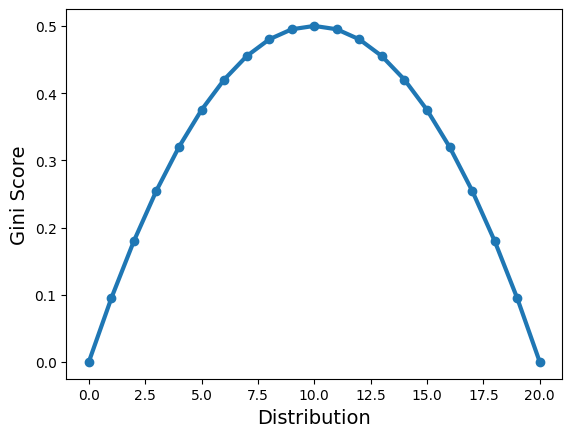

In [16]:
num_samples, gini_scores = 20, []

for num_no in range (0, num_samples+1):
    gini_scores.append(compute_gini_score_node([0]*num_no + [1]*(num_samples-num_no)))

plt.figure()
plt.plot(range(0, len(gini_scores)), gini_scores, marker='o', ls='-', lw=3)
plt.xlabel("Distribution", fontsize=14)
plt.ylabel("Gini Score", fontsize=14)
plt.show()

In short, we prefer nodes with a low Gini score.

To finally score a split, we need to compute and combine the Gini score of both the left and right child nodes. When computing the Gini score of a split, the Gini impurities of the left and right child nodes must be weighted by their respective number of samples because larger child nodes should have a greater influence on the overall split quality than smaller ones. Without weighting, a very small but pure node could incorrectly make a split appear better, even if the majority of samples remain highly impure. The method `compute_gini_score_split()` implements this idea by first computing the Gini scores for the left and righd child node and then compute their weighted sum.

In [17]:
def compute_gini_score_split(t_left, t_right):
    # Calculate the Gini score for the left and right node
    gini_score_left  = compute_gini_score_node(t_left)
    gini_score_right = compute_gini_score_node(t_right)
    # Calculate and return the weighted average Gini score
    return   len(t_left)/(len(t_left)+len(t_right))*gini_score_left \
           + len(t_right)/(len(t_left)+len(t_right))*gini_score_right

The code cell below shows the results of the methods for two example splits for a binary classification task for $10$ class labels in total.

In [18]:
gini_split1 = compute_gini_score_split([0, 0, 0, 0, 0, 1], [0, 1, 1, 1])
gini_split2 = compute_gini_score_split([0, 0], [0, 0, 0, 0, 1, 1, 1, 1])

print(f"Gini score of Split 1: {gini_split1:.2f}")
print(f"Gini score of Split 2: {gini_split2:.2f}")

Gini score of Split 1: 0.32
Gini score of Split 2: 0.40


Notice that Split 2 has a higher score although the left child node is completely pure. However, this node is with only $2$ samples very small, compared to the right node containing the remaining $8$ samples &mdash; and this right child node is also very impure. In contrast, both child nodes of Split 2 are quite pure and this yields a lower Gini score overall. In short, if these two splits would be our only candidate splits, we would pick Split 1.

#### Regression Tasks

When dealing with numerical target values, the notion of impurity is different compared to classes but arguably even more intuitive and easier to compute. Here, a node is completely pure if all samples in this node have the exact same target values &mdash; in other words, the variance of all target values in this node is $0$. In contrast, we call a node (very) impure if the target values of the samples in that node show high variance. In practice, we typically implement the **Means Squared Error (MSE)** which is mathematically identical to the variance. It computes the average squared deviation from the mean by dividing the sum of squared deviations by the number of samples. For example, for targets $y_i$ with mean $\bar{y}$:

$$\large
\text{MSE}(y) = \sum_{i=1}^{n} (y_i - \bar{y})^2
$$

Although Mean Squared Error (MSE) is commonly used in Decision Tree regressors, other scoring functions may be preferred depending on the problem characteristics and desired robustness. For example, Mean Absolute Error (MAE) is less sensitive to outliers than MSE, while other criteria may better reflect domain-specific objectives or asymmetric prediction costs.

Given the simple definition of MSE, its implementation is equally straightforward; see the method `compute_mse_score_node()` in the code cell below.

In [19]:
def compute_mse_score_node(y):
    # Compute the mean of both child nodes
    mean = np.mean(y) 
    # Calculate the RSS score
    mse = np.sum(np.square(y - mean)) / len(y)
    # Return the final RSS score
    return mse

In [20]:
amounts = df_loan.LOAN_AMOUNT.to_numpy()
print(f"All loan ammount (x10k):\n{amounts}\n")

mse_amounts = compute_mse_score_node(amounts)
print(f"MSE of all loan amounts: {mse_amounts}")

All loan ammount (x10k):
[28 32 30 12 15 38 20 70 34 15]

MSE of all loan amounts: 255.84


Extending the computation of the MSE from a single node to a split is done the same way as for the Gini score: we computed the weighted sum between the MSE for the left and the right node where the relative sizes of the child nodes determines the weights, as implemented by the method `compute_mse_score_split()` in the code cell below.

In [21]:
def compute_mse_score_split(y_left, y_right):
    # Calculate the MSE score for the left and right node
    mse_left  = compute_mse_score_node(y_left)
    mse_right = compute_mse_score_node(y_right)
    # Calculate and return the weighted average MSE
    return   len(y_left)/(len(y_left)+len(y_right))*mse_left \
           + len(y_right)/(len(y_left)+len(y_right))*mse_right

For example, the code cell below computes the MSEs for two arbitrary splits of the target values (i.e., loan amounts) of our toy dataset of $10$ samples.

In [22]:
mse_split1 = compute_mse_score_split([28, 32, 30, 12, 15], [38, 20, 70, 34, 15])
mse_split2 = compute_mse_score_split([15, 12, 15, 20], [32, 28, 70, 38, 30, 34])

print(f"MSE of Split 1: {mse_split1:.2f}")
print(f"MSE of Split 2: {mse_split2:.2f}")

MSE of Split 1: 219.84
MSE of Split 2: 127.03


Just by eyeballing both splits, we can see that in Split 2, the left split contains all the smallest target values and the right split the remaining values. It is therefore not surprising to see that Split 2 yields a smaller MSE than Split 1.

### Finding the Best Split

Now that we can score a candidate split (for both classification and regression task), we have everything to find the best split of a node. The approach &mdash; again, ignoring any efficiency optimization strategies here &mdash; is rather straightforward: For each feature, we check which threshold yields the lowest score (Gini or MSE). To keep the code a bit cleaner, let's first focus on finding the best split for a single feature.

The method `find_best_feature_split()` searches for the optimal threshold to split a single feature `x` in a Decision Tree. It first computes all possible candidate thresholds for the feature values and then evaluates each threshold one by one. For every candidate threshold, the method partitions the samples into a left and right subset, extracts the corresponding target values, and computes a split quality score using the provided `split_scoring_func`. Depending on the task, this scoring function may compute metrics such as Gini or MSE  for regression. During the search, the method keeps track of the split with the lowest score, since lower impurity or error corresponds to a better partition of the data. Once all thresholds have been evaluated, the method returns the best score, the corresponding threshold, and the indices defining the best split.

In [23]:
def find_best_feature_split(x, y, split_scoring_func):
    # Initialize the return values
    best_score, best_threshold, best_split = np.inf, None, None
    # Compute all possible thresholds
    thresholds = compute_thresholds(x)
    # Check all thresholds/partitions to find the one yielding the lowest Gini score
    for threshold in thresholds:
        # Generate the split for the current threshold/partition
        split = generate_split(x, threshold)
        # Split the target values w.r.t. indices
        y_left, y_right = y[split[0]], y[split[1]]
        # Compute the Gini score for the current split
        score = split_scoring_func(y_left, y_right)
        # Keep track of the key information of the split with the lowest Gini score
        if score < best_score:
            best_score, best_threshold, best_split = score, threshold, split
    # Return key information of best split
    return best_score, best_threshold, best_split

To see how the method works, let's use it to find the best split with respect to the credit score of a customer (feature index $1$ in the feature matrix). In the example code below, we consider the classification tasks. This means that we need to pass the `compute_gini_score_split()` method as input argument to compute the Gini scores for each meaningful threshold during the loop of `find_best_feature_split()`.

In [24]:
# Find best split for years of employment
best_score, best_threshold, best_split = find_best_feature_split(X_classification[:,1], y_classification, compute_gini_score_split)

indices_left, indices_right = best_split

print(f"Best score:\t{best_score:.3g}")
print(f"Best threshold:\t{best_threshold:.3g}")
print(f"Best split:\t{indices_left}, {indices_right}")

Best score:	0.167
Best threshold:	658
Best split:	[0 3 6 9], [1 2 4 5 7 8]


The result show that the best threshold is $658$ (i.e., credit), yielding a Gini score of 0.167.

Now the only thing left to do is to check all features. However, for our implementation to consider one additional step that is also done by the implementations of [scikit-learn](https://scikit-learn.org): Instead of always checking all the features, we introduce a hyperparameter `max_features` to limit the number of features we check for a split to a random subset of size `max_features`. While the Decision Tree implementation of [scikit-learn](https://scikit-learn.org) support various means to specify the size of the subset of features (absolute size, relative size, function-based), we limit ourselves to integer values for `max_features` to specify the absolute number of random features a split should consider.

The method `sample_feature_indices()` implements this idea. The method first determines the total number of available features from the input matrix `X`. If the optional argument `max_features` is provided, the method limits the number of sampled features to at most this value. It then uses [`np.random.choice()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) to randomly select feature indices without replacement, meaning the same feature cannot be chosen multiple times. The returned array contains the indices of the features that should be considered during the construction of a Decision Tree split.

In [25]:
def sample_feature_indices(X, max_features=None):
    n_features = X.shape[1]
    if max_features is not None:
        n_features = min(n_features, max_features)
    return np.random.choice(np.arange(X.shape[1]), size=n_features, replace=False)

For a quick example, the code below randomly samples $2$ indices from the original set of $4$ features five times. Note that we still use [`np.random.choice()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) even if `max_features` is not set. In other words, even if we do not reduce the number of features, the resulting list of indices will be in a random order. This can affect the choice of the split in case different thresholds yield the same lowest score (Gini or MSE).

In [26]:
for _ in range(5):
    sampled_feature_indices = sample_feature_indices(X_classification, max_features=2)
    print(f"Sampled indices: {sampled_feature_indices}")

Sampled indices: [1 2]
Sampled indices: [0 2]
Sampled indices: [3 2]
Sampled indices: [2 3]
Sampled indices: [3 2]


**Feature sampling**, i.e., the random selection of a subset of features is done on a split-by-split basis, meaning that different splits consider different random subsets. Although maybe a bit counter-intuitive, feature sample can have advantages in practice:

* If all features are always available, and a few of them are dominant (i.e., strong predictors), the tree may repeatedly select the same highly predictive features near the top of the tree, which can lead to overly specialized splits and increase the risk of overfitting. Feature sampling encourages exploring alternative patterns and relationships in the data, which can sometimes improve generalization performance.
* Feature subsampling can also reduce computational cost, especially for datasets with a very large number of features. Evaluating every possible feature and threshold at every node can become expensive, so limiting the number of candidate features speeds up training.
* When many features are noisy, redundant, or highly correlated, randomly selecting subsets of features can help prevent the model from being overly influenced by such features and may lead to a more balanced and robust tree structure.

We now have everything to find the best split. The method `find_best_split()` begins by initializing variables that will store the best split information found during the search, including the split score, the selected feature, the threshold, and the resulting partition of the samples. The method then performs feature sampling using `sample_feature_indices()`, which can optionally restrict the number of features considered during split evaluation. Then, the method iterates over the features of the dataset column by column. For each feature, it extracts the corresponding feature values and calls `find_best_feature_split()` to determine the best threshold for splitting that specific feature. The resulting split is evaluated using the provided scoring function (Gini or MSE). If the current split achieves a lower score than all previously evaluated splits, the method updates the stored best split information. After all features have been evaluated, the method returns the score, feature index, threshold, and partition corresponding to the best overall split.

In [27]:
def find_best_split(X, y, split_scoring_func, max_features=None):
    # Initialize the return values
    best_score, best_feature, best_threshold, best_split = np.inf, None, None, None
    # Perform feature sampling
    sampled_feature_indices = sample_feature_indices(X, max_features=max_features)
    # Check for each feature (i.e., each column in X), which split has the best (lowest) score
    for feature in range(X.shape[1]):
        # Extract feature values from datasets
        x = X[:,feature]
        # Calculate the best split for the current column/feature
        score, threshold, split = find_best_feature_split(x, y, split_scoring_func)
        # Keep track of the key information of the split with the lowest Gini score
        if score <= best_score:
            best_score, best_feature, best_split, best_threshold = score, feature, split, threshold
    # Return the best split together with the relevant information
    return best_score, best_feature, best_threshold, best_split

Using `find_best_split()`, we can now find the best root split for our toy dataset; again, we consider the classification task for the example below. It obviously is the root split since we pass the complete feature matrix and target vector to the method.

In [28]:
# Find best split (without feature sampling)
best_score, best_feature, best_threshold, best_split = find_best_split(X_classification, y_classification, compute_gini_score_split)

indices_left, indices_right = best_split

print(f"Best score:\t{best_score:.3g}")
print(f"Best feature:\t{best_feature} (index)")
print(f"Best threshold:\t{best_threshold:.3g}")
print(f"Best split:\t{indices_left}, {indices_right}")

Best score:	0.167
Best feature:	3 (index)
Best threshold:	4
Best split:	[0 3 6 9], [1 2 4 5 7 8]


According to the output, the best split is using Feature $3$ (i.e., years of employment) with a threshold of $4$. Notice how this matches the root split in the Decision Tree we trained and visualized at the very beginning. In principle, the result could have been different in the case that several splits would have the same lowest score (here: Gini).

### Recursive Splitting

We now know how to find the best split for a current node. This is arguably the core operation of the Decision Tree learning algorithm as it involves the most important as well as the most computation-intensive steps. Of course, training a proper Decision Tree goes beyond splitting a single node. However, this last component to the algorithm is pretty straightforward.

#### Basic Approach

In the previous example, we used the complete dataset to find the best split. This is equivalent to finding the root split. After the split, some of the data samples will be in the new left child node, and the other samples will be in the right child node &mdash; recall, we only consider binary splits. In other words, both child nodes now contain two non-overlapping subsets of the dataset. This process now continues by further splitting these child nodes using the same methods, and so. In terms of implementation, we call the `find_best_split()` method for both child nodes. If you are interested in the exact implementation, you can have a look at the `fit()` and `_fit()` method of the class `SeleneDecisionTree` in the file `src/model/tree/dtree.py`.

The only question we still need to address is when this recursive splitting of child nodes will stop. This is what we talk about next.

#### Stopping Criteria

Recall that when finding the best split, we favor nodes that are 100% pure &mdash; that is, the targets of all samples in this node either have the same label (classification) or the value (regression). In the extreme case this means the node may contain only a single data sample. Both the Gini score and the MSE will be $0$. This is the default stopping criteria as there is obviously no point in splitting this node any further, and it remains a leaf node in this Decision Tree. If a Decision Tree grows such that all leaf nodes have the only one or the same target label/value, we consider it as a "full" Decision Tree.

While growing a full Decision Tree often leads to extremely low training errors, it can also cause the tree to memorize noise, outliers, and random fluctuations in the training data rather than learning generalizable patterns. As a result, the model may suffer from **overfitting**, meaning it performs very well on the training set but poorly on unseen data. Deep trees also tend to create highly complex decision boundaries that are sensitive to small changes in the dataset. Another drawback of fully grown trees is that they can become computationally expensive and difficult to interpret. Large trees require more memory, increase prediction time, and may contain many splits that contribute little meaningful information. 

Thus, in practice, better generalization is often achieved by controlling the complexity of the tree using techniques such as limiting the maximum depth, requiring a minimum number of samples per node, or pruning unnecessary branches after training. In our example implementation, we consider two of arguments the Decision Tree implementations of [scikit-learn](https://scikit-learn.org) provide to stop an impure node from being split further:

* `max_depth`: The maximum depth of the tree. If `max_depth=None`, then nodes are split until all leaves are pure or until all leaves contain less than `min_samples_split` samples.

* `min_samples_split`: The minimum number of samples required to split an internal node; for simplicity, for our implementation this number is specified in absolute terms using an interger value; [scikit-learn](https://scikit-learn.org) also allows to specify this values as fraction.

Again, for full details, you can have a look at the `_fit()` method of the class `SeleneDecisionTree` in the file `src/model/tree/dtree.py`. The code is arguably quite self-explanatory.

#### Practical Implementation

So far, we have covered all the core steps of the Decision Tree Learning algorithm and provided basic implementations for each step. For a more practical use, we combined all the methods into the two classes `SeleneDecisionTreeClassifier` and `SeleneDecisionTreeRegressor`. Under the hood, both classes perform the exact same steps we have covered. Let's use the `SeleneDecisionTreeClassifier` to train a Decision Tree for the classification task of our toy dataset; in the code cell below, since we assume the default values for all arguments, we train a full tree.

In [29]:
np.random.seed(12)

classifier = SeleneDecisionTreeClassifier().fit(X_classification, y_classification)

While our custom implementation does not support any beautiful graph-based representation, the implementation still provides a simple text-based representation of the Decision Tree showing all the relevant details; the indentation naturally reflects the depth of a node in the tree.

In [30]:
print(classifier)

 X[3], threshold=4, score=0.5, samples=[1 1 0 1 0 0 1 0 0 1]
--- Leaf, gini: 0.000, samples: [1 1 1 1]
--- X[0], threshold=77, score=0.278, samples=[1 0 0 0 0 0]
------ Leaf, gini: 0.000, samples: [0 0 0 0]
------ X[3], threshold=10, score=0.5, samples=[1 0]
--------- Leaf, gini: 0.000, samples: [1]
--------- Leaf, gini: 0.000, samples: [0]



For a sanity check, we can also train a Decision Tree using the  [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class of [scikit-learn](https://scikit-learn.org) &mdash; like we did at the very beginning of the notebook.

In [31]:
np.random.seed(8)

sklearn_classifier = DecisionTreeClassifier().fit(X_classification, y_classification)

Let's plot this tree once more for direct comparison with the result of our own implementation.

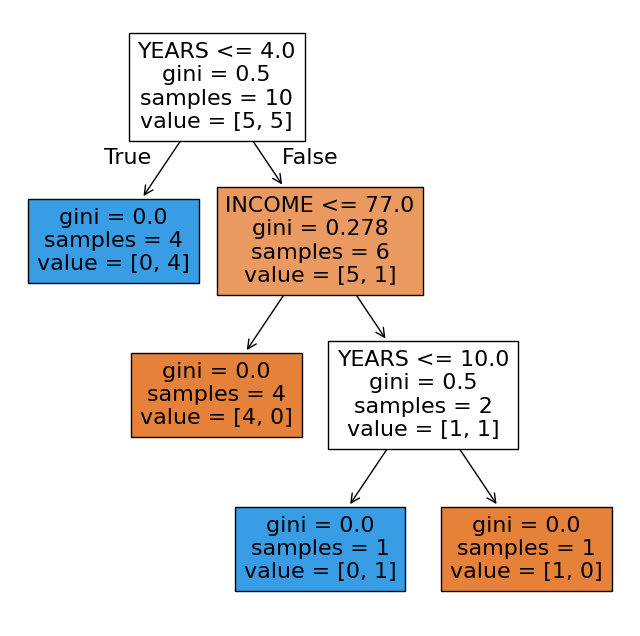

In [32]:
plt.figure(figsize=(8, 8))
plot_tree(sklearn_classifier, filled=True, feature_names=feature_names)
plt.show()

If you compare both results &mdash; the text-presentation of trained tree using our custom implementation and the graph representation of the [scikit-learn](https://scikit-learn.org) tree &mdash; you should be able to see that both trees are identical:

**Note:** Keep in mind that for different random seeds before the training, the two trees may not be identical since different candidate splits may have the same lowest score (here: Gini) and the two implementations may break up such ties differently.

We can also train a Decision Tree for the regression task of our toy dataset. The usage of the class `SeleneDecisionTreeRegressor` is exactly the same as for `SeleneDecisionTreeClassifier`. Let's first train a full Decision Tree (i.e., using the default values for all arguments) and see how it looks.

In [33]:
np.random.seed(0)

regressor = SeleneDecisionTreeRegressor().fit(X_regression, y_regression)

print(regressor)

 X[0], threshold=24.5, score=256, samples=[28 32 30 12 15 38 20 70 34 15]
--- Leaf, gini: 0.000, samples: [70]
--- X[2], threshold=0.445, score=80.8, samples=[28 32 30 12 15 38 20 34 15]
------ X[1], threshold=735, score=51.9, samples=[28 32 30 15 38 34]
--------- X[3], threshold=5.5, score=11.8, samples=[28 32 30 38 34]
------------ X[0], threshold=52.5, score=1, samples=[28 30]
--------------- Leaf, gini: 0.000, samples: [28]
--------------- Leaf, gini: 0.000, samples: [30]
------------ X[1], threshold=705, score=6.22, samples=[32 38 34]
--------------- X[3], threshold=6.5, score=4, samples=[38 34]
------------------ Leaf, gini: 0.000, samples: [34]
------------------ Leaf, gini: 0.000, samples: [38]
--------------- Leaf, gini: 0.000, samples: [32]
--------- Leaf, gini: 0.000, samples: [15]
------ X[1], threshold=622, score=10.9, samples=[12 20 15]
--------- X[1], threshold=598, score=2.25, samples=[12 15]
------------ Leaf, gini: 0.000, samples: [12]
------------ Leaf, gini: 0.000, 

The full Decision Tree for the regression task is now more complex than for the classification task. This is not surprising because regression targets are continuous values rather than a small set of discrete class labels. In classification, especially with only a few classes, many samples can often be grouped together into homogeneous leaf nodes early in the tree. Once a node predominantly contains a single class, further splits provide little improvement, so the tree can remain relatively compact. In contrast, regression trees attempt to predict precise numerical values. Since neighboring samples often have slightly different target values, the tree keeps splitting to reduce the prediction error within each leaf node. This frequently leads to many small, highly specialized regions and therefore deeper and larger trees.

Let's therefore restrict the tree by setting `max_depth=2`.

In [34]:
np.random.seed(0)

regressor = SeleneDecisionTreeRegressor(max_depth=2).fit(X_regression, y_regression)

print(regressor)

 X[0], threshold=24.5, score=256, samples=[28 32 30 12 15 38 20 70 34 15]
--- Leaf, gini: 0.000, samples: [70]
--- X[2], threshold=0.445, score=80.8, samples=[28 32 30 12 15 38 20 34 15]
------ Leaf, gini: 51.917, samples: [28 32 30 15 38 34]
------ Leaf, gini: 10.889, samples: [12 20 15]



Again, we can compare our implementation with the [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class of [scikit-learn](https://scikit-learn.org); of course, we also have to set `max_depth=2` for a meaningful comparison.

In [35]:
np.random.seed(2)

sklearn_regressor = DecisionTreeRegressor(max_depth=2).fit(X_regression, y_regression)

After plotting the trained Decision Tree...

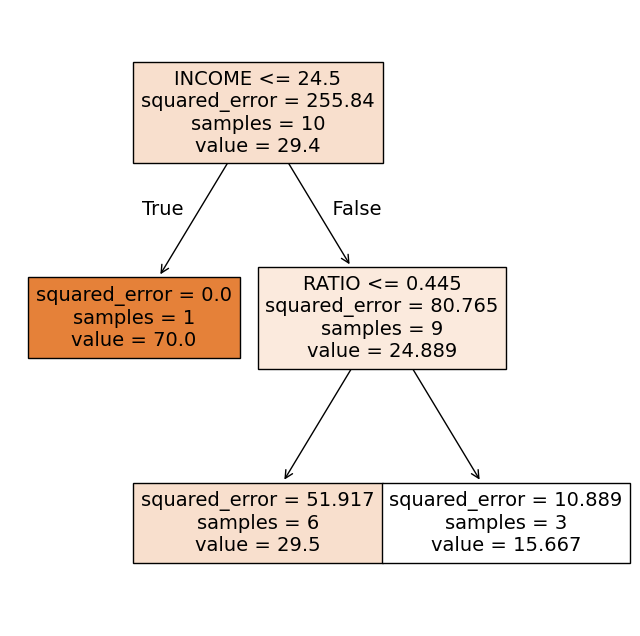

In [36]:
plt.figure(figsize=(8, 8))
plot_tree(sklearn_regressor, filled=True, feature_names=feature_names)
plt.show()

...we can easily see that both results match up; again, assuming the default random seeds.

###  Predicting Classes

The final goal of training a Decision Tree is to use it to make predictions for new data samples. Naturally, the predictions depend on whether we have a classification or regression task, but in both cases we need to find the correct leaf node and its corresponding targets (class labels or values). To make a prediction, a Decision Tree starts at the root node and follows a sequence of decision rules until it reaches a leaf node. At each internal node, the tree evaluates a condition based on one feature, such as whether a feature value is smaller or larger than a threshold. Depending on the outcome, the sample is passed to either the left or right child node.

In the code cell below, The method `get_targets_for_sample()` traverses a Decision Tree for a single input sample `x` in order to find the leaf node that corresponds to that sample. If the current node is already a leaf node, the method simply returns `node.y`, which contains all target values of the training samples that ended up in that leaf during training. Otherwise, the method checks the splitting rule stored in the node: it compares the feature value `x[node.feature_idx]` with the node's threshold. If the feature value is smaller than or equal to the threshold, the sample is passed recursively to the left child; otherwise, it is passed to the right child. This recursive process continues until a leaf node is reached.

The second method, `get_targets()`, applies this traversal process to every sample in a dataset `X`. It uses a list comprehension to call `get_targets_for_sample()` for each sample individually and returns a list containing the relevant leaf-node targets for every sample. In other words, this method determines which training targets are associated with the leaf node reached by each input sample.

In [37]:
def get_targets_for_sample(node, x):
    # If the node is a leaf, simple return all targets
    if node.is_leaf():
        return node.y
    # If the node is not a leaf, go down the left or right subtree depending on threshold
    go_left = False
    if x[node.feature_idx] <= node.threshold:
        go_left = True
    if go_left:
        return get_targets_for_sample(node.left_child, x)
    else:
        return get_targets_for_sample(node.right_child, x)        

def get_targets(X, decision_tree):
    # Return list of relevant targets for each sample
    return [ get_targets_for_sample(decision_tree, x) for x in X ]

To show an example, we can train a Decision Tree classifier using our toy dataset, and the use this tree to find all relevant targets (here: class labels) for samples in the training data &mdash; of course, these are not unseen samples, but the purpose here is only to show the application of the method `get_targets()`. To make it a bit more interesting, we set `max_depth=2` to avoid growing a full tree. This means that not all leaf nodes will be completely pure but will have labels of different classes.

In [38]:
classifier = SeleneDecisionTreeClassifier(max_depth=2).fit(X_classification, y_classification)

for i, targets in enumerate(get_targets(X_classification, classifier.tree)):
    print(f"Targets for Sample {i}:\t{targets}")

Targets for Sample 0:	[1 1 1 1]
Targets for Sample 1:	[1 0]
Targets for Sample 2:	[0 0 0 0]
Targets for Sample 3:	[1 1 1 1]
Targets for Sample 4:	[1 0]
Targets for Sample 5:	[0 0 0 0]
Targets for Sample 6:	[1 1 1 1]
Targets for Sample 7:	[0 0 0 0]
Targets for Sample 8:	[0 0 0 0]
Targets for Sample 9:	[1 1 1 1]


We can do the same for the regression task by first learning a Decision Tree regressor &mdash; again, with `max_depth=2` and then find all relevant targets for all samples in the training data. Of course, now the targets are numerical values instead of class labels.

In [39]:
regressor = SeleneDecisionTreeRegressor(max_depth=2).fit(X_regression, y_regression)

for i, targets in enumerate(get_targets(X_regression, regressor.tree)):
    print(f"Targets for Sample {i}:\t{targets}")

Targets for Sample 0:	[28 32 30 15 38 34]
Targets for Sample 1:	[28 32 30 15 38 34]
Targets for Sample 2:	[28 32 30 15 38 34]
Targets for Sample 3:	[12 20 15]
Targets for Sample 4:	[28 32 30 15 38 34]
Targets for Sample 5:	[28 32 30 15 38 34]
Targets for Sample 6:	[12 20 15]
Targets for Sample 7:	[70]
Targets for Sample 8:	[28 32 30 15 38 34]
Targets for Sample 9:	[12 20 15]


This core step of finding the relevant targets for a sample is the same for Decision Tree classifiers and regressors. The final prediction, however, depends on whether we have a classification or regression task. In the case of a classification task, the Decision Tree classifier then predicts the most frequent class label among these targets, following the intuition that samples ending up in the same leaf are likely to belong to the same class. In some cases, multiple class labels may occur with the same highest frequency within a leaf node. Such ties can be resolved randomly by selecting one of the equally frequent classes at random. This ensures that the classifier can still produce a single prediction even when the class distribution in the leaf is ambiguous.

The method `predict_classes()` below implements this simple approach. The method first calls the method `get_targets()` to determine the relevant target values for every input sample in `X`; see above. The second step computes the predicted class for each sample. The expression `np.bincount(t)` counts how often each integer class label occurs in the target list `t`, and `.argmax()` returns the index of the most frequent class. Thus, the method predicts the majority class label among the training samples stored in the corresponding leaf node. The final result is a list containing one predicted class label for each sample in `X`.

In [40]:
def predict_classes(X, decision_tree_classifier):
    # Get the targets for all samples
    targets = get_targets(X, decision_tree_classifier.tree)
    # Return the majory class for each sample
    return [ np.bincount(t).argmax() for t in targets ]

As before, let's train a Decision Tree classifier on our toy dataset but now predict the class labels for all samples in the training data. Notice that in the code below, we do not set `max_depth` like in the previous example to grow a full tree. This is simple to ensure that the predictions for all samples will match the ground truth labels.

In [41]:
classifier = SeleneDecisionTreeClassifier().fit(X_classification, y_classification)

for i, label in enumerate(predict_classes(X_classification, classifier)):
    print(f"Predicted class for Sample {i}:\t{label}")

Predicted class for Sample 0:	1
Predicted class for Sample 1:	1
Predicted class for Sample 2:	0
Predicted class for Sample 3:	1
Predicted class for Sample 4:	0
Predicted class for Sample 5:	0
Predicted class for Sample 6:	1
Predicted class for Sample 7:	0
Predicted class for Sample 8:	0
Predicted class for Sample 9:	1


If you compare the predictions with the ground truth labels shown at the beginning, you will find that they match up.

When dealing with regression tasks, computing the final prediction is even more straightforward: Given the list of target values for an input sample, the final prediction is simply the mean of all target values. The intuition is that samples grouped into the same leaf are assumed to have similar target values, so the average provides a reasonable prediction. The method `predict_values()` below, again, first calls `get_targets()` to determine the relevant target values for every input sample in `X`. It computes the regression prediction for each sample by taking the mean of the corresponding target values using `np.mean(t)`.The method finally returns a list containing one predicted numerical value for each sample in `X`.

In [42]:
def predict_values(X, decision_tree_regressor):
    # Get the targets for all samples
    targets = get_targets(X, decision_tree_regressor.tree)
    # Return the mean value for each sample
    return [ np.mean(t) for t in targets ]

Thus, we can now train a Decision Tree regressor and use this regressor to predict the values for each sample in the training data. Again, we grow a full Decision tree in the example below so that the predictions again match the ground truth values.

In [43]:
regressor = SeleneDecisionTreeRegressor().fit(X_regression, y_regression)

for i, value in enumerate(predict_classes(X_regression, regressor)):
    print(f"Predicted value for Sample {i}:\t{value}")

Predicted value for Sample 0:	28
Predicted value for Sample 1:	32
Predicted value for Sample 2:	30
Predicted value for Sample 3:	12
Predicted value for Sample 4:	15
Predicted value for Sample 5:	38
Predicted value for Sample 6:	20
Predicted value for Sample 7:	70
Predicted value for Sample 8:	34
Predicted value for Sample 9:	15


Now that we are able to make predictions, we covered all the core steps required to train and use a Decision Tree for classification and regression tasks. Keep in mind, of course, that no emphasis was placed on efficiency or other customization provided by more mature implementations such as the ones of [scikit-learn](https://scikit-learn.org).

---

## Worked Example

To conclude this notebook, let's use our Decision Tree implementation to apply on a real-world dataset. The [*"Breast Cancer Wisconsin (Diagnostic)"*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) dataset is a widely used binary classification dataset for predicting whether a breast tumor is malignant (cancerous) or benign (non-cancerous). The dataset was created from digitized images of fine needle aspirate (FNA) tests of breast masses, where image processing techniques were used to extract numerical features describing characteristics of the cell nuclei present in the images. These features include measurements such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

The dataset contains 569 samples with 30 numerical input features and a binary target label indicating the diagnosis. It is commonly used in machine learning education and research because it is relatively small, clean, and well-structured, making it suitable for demonstrating classification algorithms such as Random Forests. Let's load the dataset into a Pandas DataFrame and have a look.

In [44]:
df_cancer = pd.read_csv(breast_cancer)

df_cancer.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis
0,20.48,21.46,132.50,1306.0,0.08355,0.08348,0.09042,0.06022,0.1467,0.05177,...,26.17,161.70,1750.0,0.1228,0.23110,0.31580,0.14450,0.2238,0.07127,1
1,13.15,15.34,85.31,538.9,0.09384,0.08498,0.09293,0.03483,0.1822,0.06207,...,20.50,97.67,677.3,0.1478,0.22560,0.30090,0.09722,0.3849,0.08633,0
2,10.17,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,17.45,69.86,368.6,0.1275,0.09866,0.02168,0.02579,0.3557,0.08020,0
3,14.90,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,...,27.57,125.40,832.7,0.1419,0.70900,0.90190,0.24750,0.2866,0.11550,1
4,20.73,31.12,135.70,1419.0,0.09469,0.11430,0.13670,0.08646,0.1769,0.05674,...,47.16,214.00,3432.0,0.1401,0.26440,0.34420,0.16590,0.2868,0.08218,1


Apart from its small size, this dataset is also convenient since all the input features are numerical, and thus not requiring any encoding strategies &mdash; as we would need to convert categorical features into numerical ones. Also, recall that Decision Trees do not require normalization or standardization of the features since they do not take the interaction between features into account: each split is based on a single feature. As such, different features can have values of very different magnitudes. We can therefore directly extract the feature matrix `X` and the target vector `y` from the DataFrame.

In [45]:
X_cancer = df_cancer.iloc[:, 0:-1].to_numpy()
y_cancer = df_cancer.iloc[:, -1].to_numpy().squeeze()

In contrast to our toy dataset, we split the breast cancer dataset into a training and test set to evaluate any trained model using unseen data samples. For convenience, we use the method the [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) method of [scikit-learn](https://scikit-learn.org) for that. As a default, we allocate 25% of the dataset to form the test set.

In [46]:
# Split dataset in training and test data (25% test data)
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.25, random_state=0)

print(f"Size of training dataset: {len(X_train)}")
print(f"Size of test dataset: {len(X_test)}")

Size of training dataset: 426
Size of test dataset: 143


We are now ready to use our `SeleneDecisionTreeClassifier` class to train a model, simply by calling the `fit()` method on the training data. In the example below, we assume the default values for all hyperparameters (i.e., `max_features`, `min_samples_split`, `max_features`), which most importantly means that we are growing a full tree. Note that we purposefully do not set a random seed, so you can run the code cell multiple times and see that the evaluation results will slightly differ between runs.

In [47]:
selene_decision_tree = SeleneDecisionTreeClassifier().fit(X_train, y_train)

You might notice that running the previous code cell to train the Decision Tree classifier might actually take a few seconds. Again, recall that our implementation focused on understanding the core steps of the Decision Tree learning algorithm and not on efficiency. In any case, we can now use our trained classifier to predict the class labels for the test set and evaluate the model against the ground truth. For this, we use the  method [`classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) from [scikit-learn](https://scikit-learn.org) to generate a summary of the performance of a classification model. It compares the true class labels with the predicted labels and computes evaluation metrics such as precision, recall, F1-score, and support for each class. The report also typically includes overall averages, helping assess how well the classifier performs across all classes.

In [48]:
y_pred = selene_decision_tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        93
           1       0.85      0.94      0.90        50

    accuracy                           0.92       143
   macro avg       0.91      0.93      0.92       143
weighted avg       0.93      0.92      0.92       143



For a sanity check, we also train a classifier using the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class of [scikit-learn](https://scikit-learn.org).

In [49]:
sklearn_decision_tree = DecisionTreeRegressor().fit(X_train, y_train)

You will notice that the training using this implementation is much faster, and the difference would be more and more pronounced for larger datasets. The [scikit-learn](https://scikit-learn.org) implementations are much more mature and optimized, and should therefore be preferred for any practical applications.

Lastly, let's see how the model performs on the test data.

In [50]:
y_pred = sklearn_decision_tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        93
           1       0.89      0.94      0.91        50

    accuracy                           0.94       143
   macro avg       0.93      0.94      0.93       143
weighted avg       0.94      0.94      0.94       143



Overall, you should see that the result of our implementation and the one of [scikit-learn](https://scikit-learn.org) should be very comparable or even identical. The fact that they are not always identical, despite growing full trees, is that the training and the prediction still involves nondeterministic step when comes to breaking up ties &mdash; for example, when two or more splits have the same lowest score during training, or when a leaf node has an equal distribution of class labels during prediction.

**Discussion:** Note that this worked example only focused on the usage of the two custom classes `SeleneDecisionTreeClassifier` and `SeleneDecisionTreeClassifier`. In practice, particularly when working with real-world data, we would also need to perform hyperparameter tuning using cross validation to actually find the best values for `max_depth`, `min_samples_split`, and `max_features` &mdash; the implementations of [scikit-learn](https://scikit-learn.org) provide even more hyperparameters. However, hyperparameter tuning is beyond the scope of this notebook.

---

## Summary

This notebook presented a **from-scratch implementation of Decision Trees** for both classification and regression tasks while closely mimicking the design and behavior of the implementations provided by [scikit-learn](https://scikit-learn.org). The goal was not merely to build a working model, but to look "under the hood" of the Decision Tree learning algorithm and gain a deeper understanding of how trees recursively partition the feature space. By implementing the core components manually &mdash; including split evaluation, impurity scoring, recursive tree growth, and prediction &mdash; the notebook illustrated the fundamental ideas that make Decision Trees effective supervised learning models.

An important takeaway from the notebook was that Decision Trees are **greedy learning** algorithms that repeatedly perform locally optimal splits in order to construct a hierarchical representation of the data. The notebook also illustrated practical considerations such as stopping criteria, overfitting in fully grown trees, and the role of hyperparameters such as maximum depth or minimum samples per split. Understanding these aspects helps explain both the strengths and limitations of Decision Trees in real-world machine learning applications.

A solid understanding of Decision Trees is particularly valuable because they form the foundation of many more **advanced tree-ensemble methods**. Models such as Random Forests and Gradient Boosted Trees build directly upon the principles introduced by single Decision Trees and often achieve state-of-the-art performance on structured or tabular datasets. Consequently, understanding how individual Decision Trees operate provides important intuition for understanding why these more sophisticated ensemble techniques work so well in practice.